# CASALS L1B waveform gallery
Six real pulse examples separate **waveform morphology** from **land-cover interpretation**. A multi-component waveform is not proof of forest; a single prominent component is not proof of ground. Official Refh is associated with the raw RX maximum-amplitude bin. Detected components remain waveform-derived candidates.

Two independently selectable default pulses come from the historically tree-covered November 18 AOI. Other cases are selected by the existing detector features and retain unknown land cover. A low-SNR case is always included.

## Inputs and configuration
The default AOI is pinned from visual evidence, without requiring Notebook 05 outputs. Existing feature tables are located through metadata outputs. Only the selected few RX/TX records are read for plots.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import h5py, rasterio
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'casals_l1b').is_dir():
    raise RuntimeError('Start Jupyter in the CASALS repository root.')
sys.path.insert(0, str(ROOT))
from research.showcase import *
GRANULES = sorted((ROOT / 'data/raw/casals_l1b').glob('casals_l1b_202411*T*_001_02.h5'))
if len(GRANULES) != 2:
    raise FileNotFoundError('Expected the November 12 and November 18, 2024 L1B granules in data/raw/casals_l1b.')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11, 'axes.spines.top':False,
                     'axes.spines.right':False, 'savefig.dpi':220, 'axes.titleweight':'bold'})
SEED = 42
DPI = 220
from casals_l1b.waveform import build_record_index_grid, infer_waveform_record_axis, read_waveform_records
from casals_l1b.waveform import detect_candidate_components_1d, classify_prominent_components, preprocess_waveform
from casals_l1b.peaks_cli import default_config, build_detector_config, extract_components
from pyproj import Transformer
H5_PATH = GRANULES[1]
OUTPUT_DIR = ROOT / 'outputs/notebooks/06_waveform_gallery' / H5_PATH.stem
AOI = [347970.,4005970.,348130.,4006130.]
SELECTED_PULSE_INDEX = None  # Optional first-case override; land cover becomes unknown
CONTEXT_HALF_WIDTH_M = 25.
DEFAULT_CANOPY_PULSES = [2128614,2085162]  # stable, spatially reviewed historical-tree-cover locations
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)


## Existing detector features and selection
Reuse the production detector thresholds and preprocessing unchanged. Selection is deterministic: two spatial examples, a concentrated high-SNR case, the most prominent components, the broadest remaining main component and the lowest-SNR remaining case. “Broadest selected” is relative to the available subset, not necessarily the detector's absolute broad-peak flag. If a feature table is unavailable, extract only three fixed sweeps through the existing API into this notebook directory.

In [2]:
try:
    feature_outputs, feature_metadata = find_products(H5_PATH,'pulse_summary_parquet')
except FileNotFoundError:
    cfg = default_config([H5_PATH],OUTPUT_DIR/'feature_subset')
    cfg.write_diagnostic_png = False
    extract_components(H5_PATH,sweep_selection=[5000,5001,5002],config=cfg,output_dir=OUTPUT_DIR/'feature_subset')
    feature_outputs, feature_metadata = find_products(H5_PATH,'pulse_summary_parquet')
pulse_features = pd.read_parquet(feature_outputs['pulse_summary_parquet'])
components_existing = pd.read_parquet(feature_outputs['component_table_parquet'])
feature_run = json.loads(feature_metadata.read_text())
cfg = default_config([H5_PATH],OUTPUT_DIR)
for key,value in feature_run.get('config',{}).items():
    if hasattr(cfg,key) and key not in ['input_h5_paths','output_root']:
        setattr(cfg,key,value)
detector_config = build_detector_config(cfg)
selected = []
if H5_PATH.stem == 'casals_l1b_20241118T171757_001_02':
    selected = [(i,'Spatial canopy-context example','probable tree canopy','probable') for i in DEFAULT_CANOPY_PULSES]
def add_feature_case(frame, keys, ascending, title):
    available = frame[~frame.pulse_index.isin([i[0] for i in selected])].dropna(subset=keys)
    if available.empty:
        raise RuntimeError(f'No available feature case: {title}')
    row = available.sort_values(keys+['pulse_index'],ascending=ascending+[True],kind='stable').iloc[0]
    selected.append((int(row.pulse_index),title,'unknown','unknown'))
single = pulse_features[pulse_features.n_prominent_components==1]
add_feature_case(single if len(single) else pulse_features,['refh_snr'],[False],'Single prominent component / high SNR')
add_feature_case(pulse_features,['n_prominent_components','refh_snr'],[False,False],'Multiple detected components')
add_feature_case(pulse_features,['main_peak_width_bins'],[False],'Broadest selected main component')
add_feature_case(pulse_features,['refh_snr'],[True],'Low SNR / ambiguous')
if SELECTED_PULSE_INDEX is not None:
    selected[0] = (int(SELECTED_PULSE_INDEX),'User-selected pulse','unknown','unknown')
assert len(set(i[0] for i in selected))==len(selected)
print('Feature table:',relative(feature_outputs['pulse_summary_parquet']))
display(pd.DataFrame(selected,columns=['pulse_index','selection_target','land_cover','confidence']))


Feature table: outputs/notebooks/03_waveform_analysis/peaks/casals_l1b_20241118T171757_001_02/pulse_summary.parquet


,pulse_index,selection_target,land_cover,confidence
0,2128614,Spatial canopy-context example,probable tree canopy,probable
1,2085162,Spatial canopy-context example,probable tree canopy,probable
2,1280702,Single prominent component / high SNR,unknown,unknown
3,1280420,Multiple detected components,unknown,unknown
4,1280230,Broadest selected main component,unknown,unknown
5,1280439,Low SNR / ambiguous,unknown,unknown


## Bounded waveform reads and pulse identity
The sweep/track grid supplies the actual H5 flat-record mapping. It is checked for duplicates and selected identities; no flat-order formula is assumed. Raw RX argmax is checked against reused feature rows. For each plotted pulse, the detector is rerun with the saved configuration and its bins are compared with existing component rows where available.

Official Refh association follows the current data contract. An inverse H2 coordinate fraction is also recorded: the tiny difference from the integer raw argmax reflects internal geometry/correction semantics, not an independently measured positional error.

In [3]:
ids = [i[0] for i in selected]
rows = []
with h5py.File(H5_PATH,'r') as h5:
    index = build_record_index_grid(h5)
    assert index.duplicate_sweep_track_cells==0
    rx_axis = infer_waveform_record_axis(h5['rx_waveform'],index.n_records)
    tx_axis = infer_waveform_record_axis(h5['tx_waveform'],index.n_records)
    rx = read_waveform_records(h5['rx_waveform'],rx_axis,ids)
    tx = read_waveform_records(h5['tx_waveform'],tx_axis,ids)
    names = ['refh_longitude','refh_latitude','refh','refh_snr','bg_mean','bg_std','refh_thres',
             'rwstart_longitude','rwstart_latitude','rwstart','rwstop_longitude','rwstop_latitude','rwstop']
    scalar = {name:np.array([h5[name][i] for i in ids]) for name in names}
    source_attrs = {k:str(v) for k,v in h5.attrs.items()}
ACQUISITION_DATE = source_attrs['start_utca'].split('T')[0]
to_xyz = Transformer.from_crs(4979,4978,always_xy=True)
processed = []; components = []
for j,(pulse,target,land,confidence) in enumerate(selected):
    sweep,track = int(index.sweep_num[pulse]),int(index.track_num[pulse])
    assert index.record_index_grid[sweep,track]==pulse
    y = rx[j];b = int(np.argmax(y))
    old = pulse_features[pulse_features.pulse_index==pulse]
    if len(old):
        assert int(old.iloc[0].sweep_num)==sweep and int(old.iloc[0].track_num)==track
        assert int(old.iloc[0].raw_argmax_bin)==b
    args = dict(y_raw=y,bg_mean=scalar['bg_mean'][j],bg_std=scalar['bg_std'][j],refh_thres=scalar['refh_thres'][j],config=detector_config)
    comp = classify_prominent_components(detect_candidate_components_1d(**args),detector_config)
    components.append(comp);processed.append(preprocess_waveform(**args))
    previous = components_existing[components_existing.pulse_index==pulse]
    if len(old):
        np.testing.assert_allclose(sorted(c['peak_bin'] for c in comp),sorted(previous.peak_bin),rtol=0,atol=1e-10)
    p0=np.array(to_xyz.transform(scalar['rwstart_longitude'][j],scalar['rwstart_latitude'][j],scalar['rwstart'][j]))
    p1=np.array(to_xyz.transform(scalar['rwstop_longitude'][j],scalar['rwstop_latitude'][j],scalar['rwstop'][j]))
    ref=np.array(to_xyz.transform(scalar['refh_longitude'][j],scalar['refh_latitude'][j],scalar['refh'][j]))
    fraction=np.dot(ref-p0,p1-p0)/np.dot(p1-p0,p1-p0)
    main=next((c for c in comp if c.get('is_main_component')),comp[0] if comp else {})
    prominent=sum(bool(c.get('is_prominent_component',False)) for c in comp)
    # Preserve the exact established summary flags/counts when the feature row exists.
    count=int(old.iloc[0].n_prominent_components) if len(old) else prominent
    width_value=old.iloc[0].main_peak_width_bins if len(old) else main.get('width_bins',np.nan)
    width=float(width_value) if pd.notna(width_value) else np.nan
    morphology=('Multiple components / low SNR' if scalar['refh_snr'][j]<5 and count>1 else 'Low SNR / ambiguous' if scalar['refh_snr'][j]<5 else
                'Multiple detected components' if count>1 else 'Single prominent component' if count==1 else 'Ambiguous waveform')
    if 'Broadest' in target: morphology=f'Broadest selected main component ({width:.1f} bins)'
    rows.append(dict(case=chr(65+j),h5=H5_PATH.name,pulse_index=pulse,sweep_num=sweep,track_num=track,
                     longitude=float(scalar['refh_longitude'][j]),latitude=float(scalar['refh_latitude'][j]),
                     refh_height_m=float(scalar['refh'][j]),SNR=float(scalar['refh_snr'][j]),
                     raw_argmax_bin=b,refh_associated_bin=b,inverse_H2_refh_bin=float(fraction*len(y)-.5),
                     H2_closure_m=float(np.linalg.norm(bin_to_xyz(p0,p1,b,len(y))-ref)),
                     n_candidate_components=len(comp),n_prominent_components=count,main_peak_width_bins=width,
                     has_broad_main_peak=bool(width>=detector_config['broad_main_width_bins']),
                     waveform_type=morphology,selection_target=target,land_cover=land,confidence=confidence))
case_table=pd.DataFrame(rows)
display(case_table[['case','pulse_index','sweep_num','track_num','SNR','waveform_type','land_cover']])


,case,pulse_index,sweep_num,track_num,SNR,waveform_type,land_cover
0,A,2128614,8314,55,9.064649,Multiple detected components,probable tree canopy
1,B,2085162,8145,81,8.489872,Single prominent component,probable tree canopy
2,C,1280702,5002,245,17.025259,Single prominent component,unknown
3,D,1280420,5001,37,3.979274,Multiple components / low SNR,unknown
4,E,1280230,5000,55,1.813438,Broadest selected main component (28.7 bins),unknown
5,F,1280439,5001,189,1.350738,Low SNR / ambiguous,unknown


## Independent spatial context
Small NAIP RGB crops use service georeferencing and retain source catalog acquisition dates, original tile CRS/datum and returned export extent. Historical tree cover is visible at the two pinned canopy-context locations; they retain probable labels because NAIP predates CASALS and exact footprint registration is unvalidated. Red crosses show Refh locations, not calibrated footprint polygons. A centre point alone cannot determine all contributing land cover.

Signal-selected cases remain unknown even where the local image suggests a likely cover. The spatial evidence board is retained for further team review.

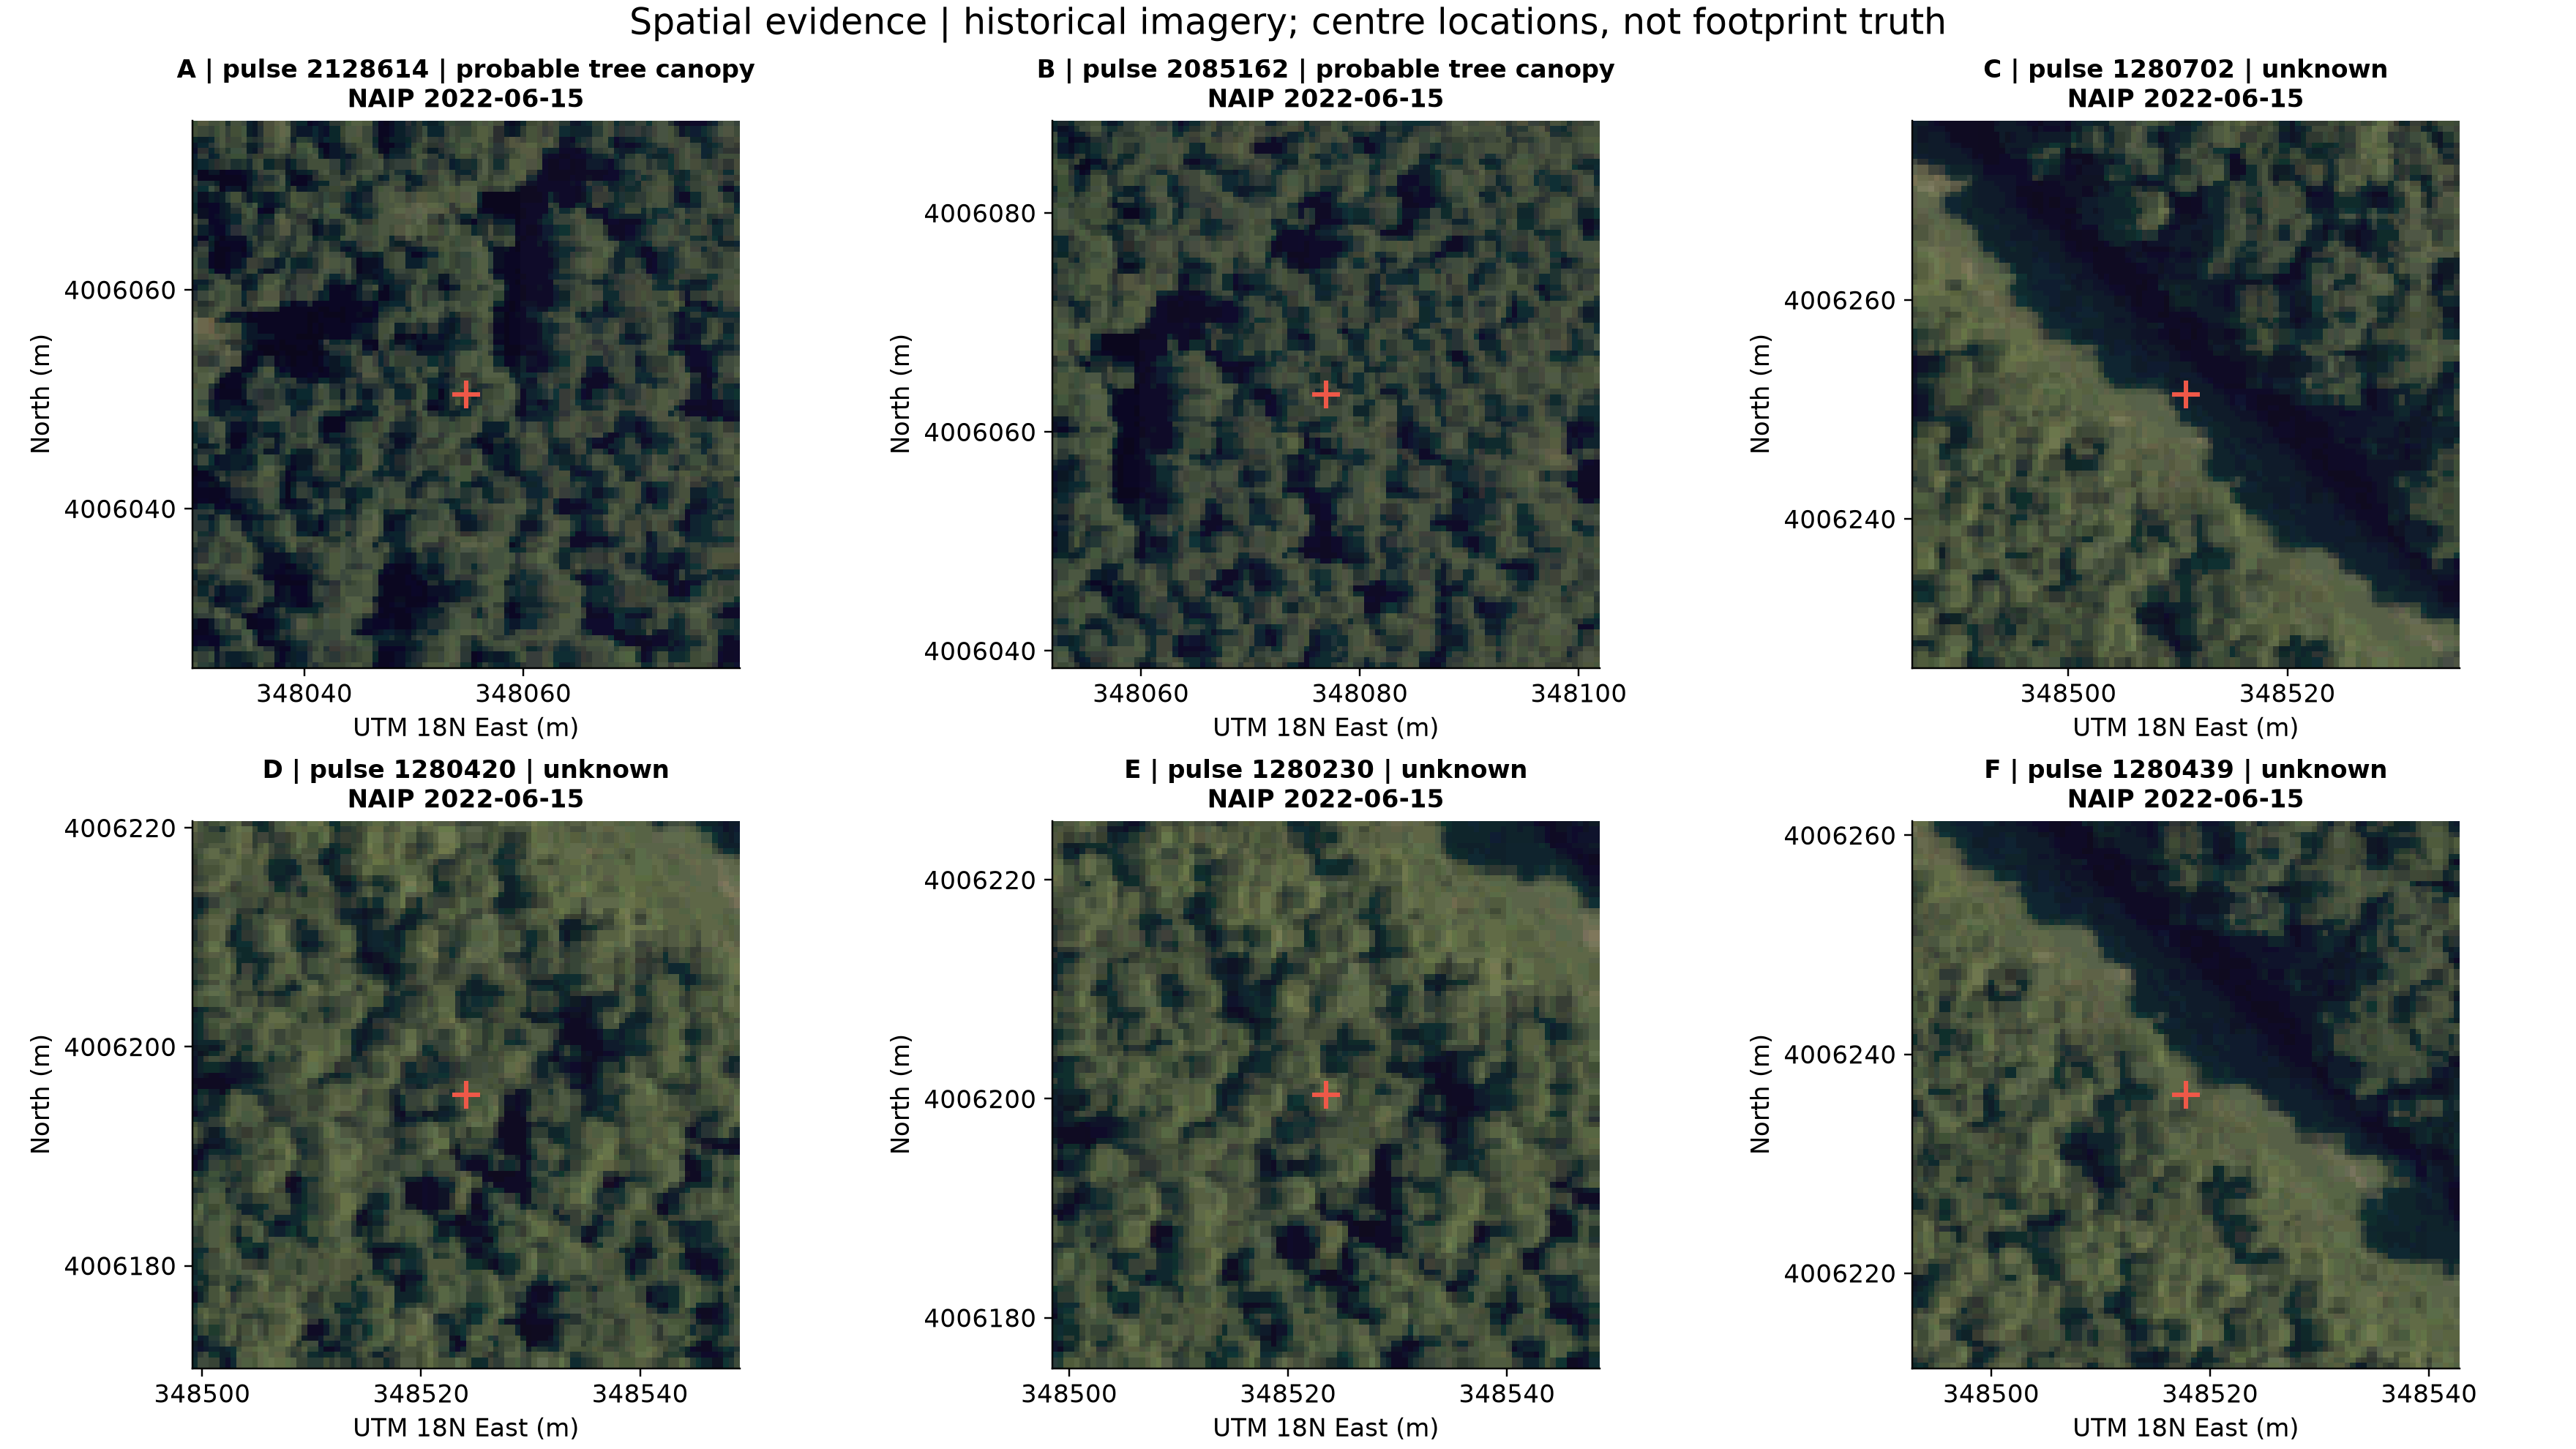

In [4]:
case_xy=np.column_stack(Transformer.from_crs(4326,32618,always_xy=True).transform(case_table.longitude,case_table.latitude))
evidence_paths=[]
for j,row in case_table.iterrows():
    x,y=case_xy[j]
    path=OUTPUT_DIR/f'case_{row["case"]}_naip.tif'
    meta=fetch_naip([x-CONTEXT_HALF_WIDTH_M,y-CONTEXT_HALF_WIDTH_M,x+CONTEXT_HALF_WIDTH_M,y+CONTEXT_HALF_WIDTH_M],32618,path)
    evidence_paths.append(path)
    case_table.loc[j,'evidence_source']=NAIP_SERVICE
    case_table.loc[j,'evidence_dates']=','.join(meta['acquisition_dates'])
    case_table.loc[j,'evidence_provenance']=relative(path.with_suffix('.json'))
    case_table.loc[j,'evidence_image']=relative(path)
    case_table.loc[j,'evidence_registration']='Service georeferencing; no fitted adjustment; footprint alignment unvalidated'
    case_table.loc[j,'interpretation']=('Historical NAIP shows tree cover at this location. ' if row.confidence=='probable' else 'Land cover remains unknown. ')+f'{row.waveform_type} at SNR {row.SNR:.2f}. Official Refh is associated with the raw RX maximum; additional components are unvalidated waveform-derived candidates.'
fig,axes=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
for j,ax in enumerate(axes.flat):
    if j>=len(case_table):ax.set_visible(False);continue
    row=case_table.iloc[j];show_ortho(ax,evidence_paths[j]);x,y=case_xy[j]
    ax.scatter(x,y,c='#ef5848',marker='+',s=150,lw=2)
    ax.set_title(f'{row["case"]} | pulse {row.pulse_index} | {row.land_cover}\nNAIP {row.evidence_dates}',fontsize=11)
    ax.set_xlabel('UTM 18N East (m)');ax.set_ylabel('North (m)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3));ax.yaxis.set_major_locator(plt.MaxNLocator(3))
fig.suptitle('Spatial evidence | historical imagery; centre locations, not footprint truth',fontsize=16)
fig.savefig(OUTPUT_DIR/'waveform_gallery_evidence.png',dpi=DPI);plt.close(fig)
display(Image(filename=str(OUTPUT_DIR/'waveform_gallery_evidence.png')))


## Waveform gallery board
Every case retains its own amplitude range in raw digital counts. No amplitude normalization or reflectance interpretation is used. Markers identify the raw maximum, official Refh-associated bin and existing detector component bins. Detector peaks are selected on the established processed waveform, then displayed at their raw-bin amplitudes. Insets show the full RX window; the main view focuses on the signal region without changing samples. TX is recorded separately and has no shared range interpretation with RX.

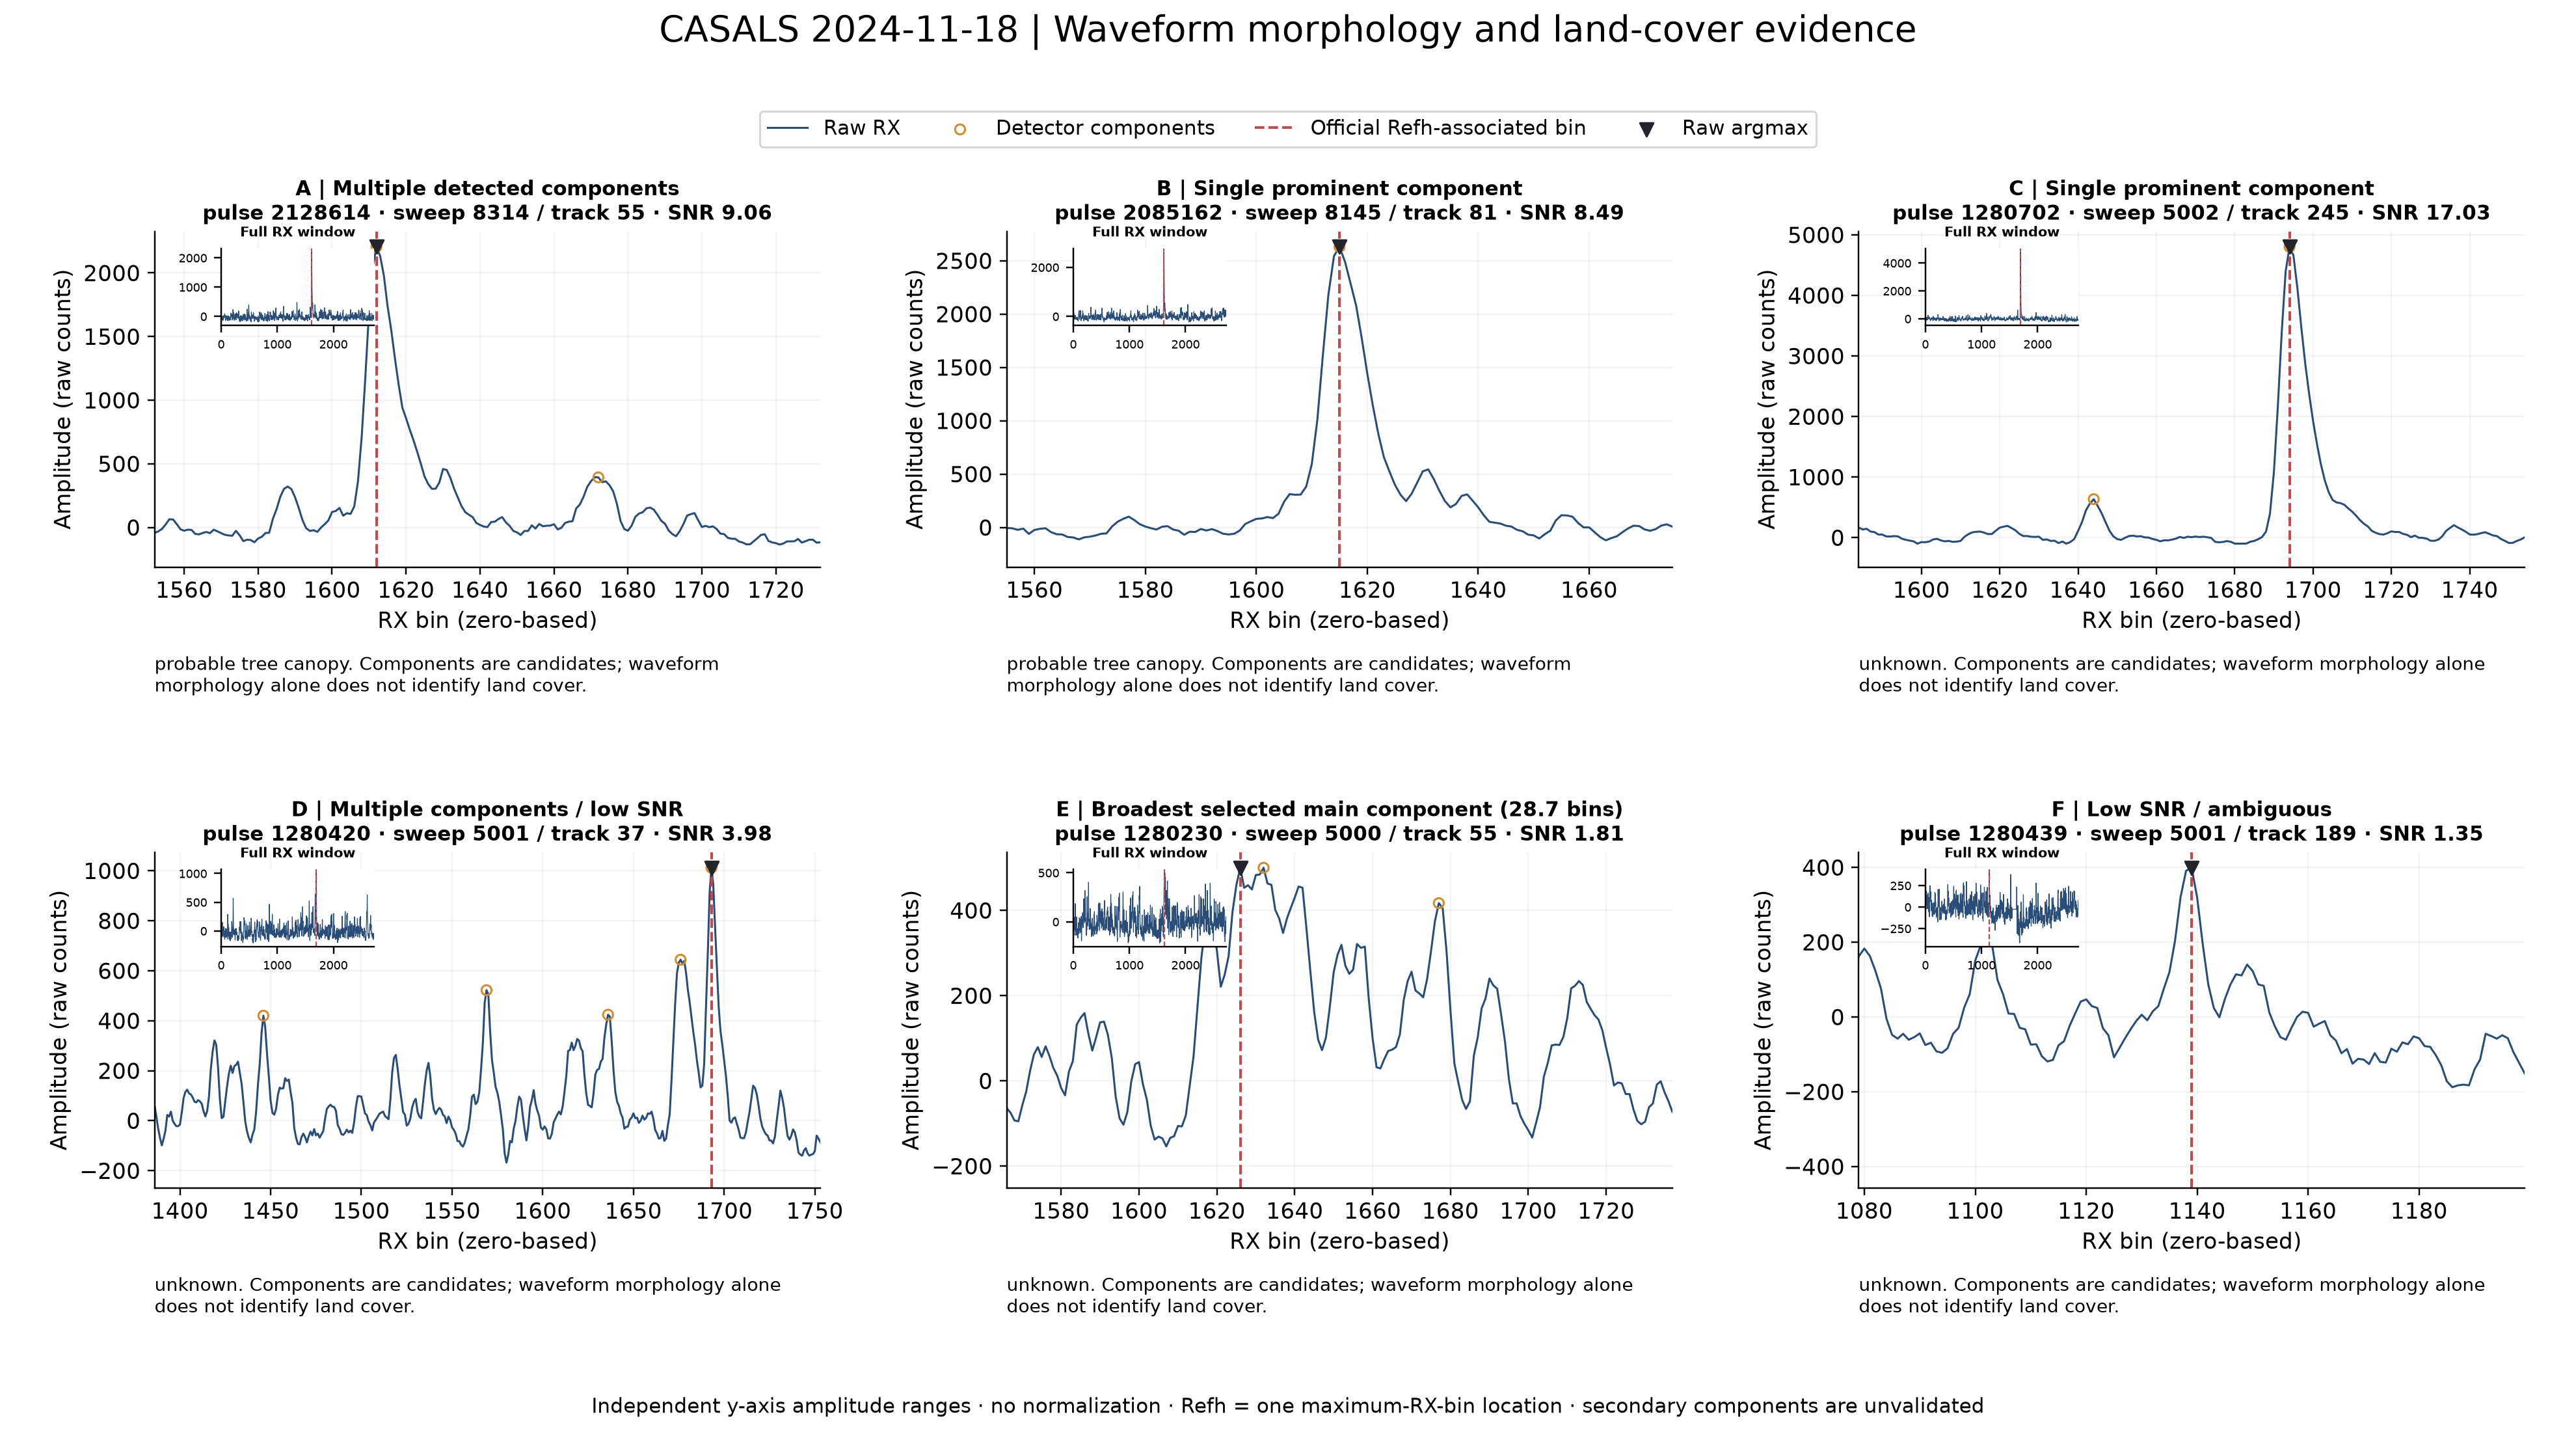

In [5]:
import textwrap
fig,axes=plt.subplots(2,3,figsize=(18,10.125))
fig.subplots_adjust(left=.06,right=.98,bottom=.18,top=.84,hspace=.85,wspace=.28)
for j,ax in enumerate(axes.flat):
    if j>=len(case_table):ax.set_visible(False);continue
    row=case_table.iloc[j];y=rx[j];bins=np.arange(len(y));b=int(row.raw_argmax_bin)
    ax.plot(bins,y,color='#274d78',lw=1,label='Raw RX')
    cb=np.array([c['peak_bin'] for c in components[j]])
    if len(cb):
        ax.scatter(cb,np.interp(cb,bins,y),marker='o',s=25,facecolors='none',edgecolors='#d38c2d',label='Detector components',zorder=4)
    ax.axvline(b,color='#c44849',lw=1.3,ls='--',label='Official Refh-associated bin')
    ax.scatter([b],[y[b]],c='#21252b',s=45,marker='v',label='Raw argmax',zorder=5)
    relevant=np.r_[b,cb[np.abs(cb-b)<250]]
    ax.set_xlim(max(0,relevant.min()-60),min(len(y)-1,relevant.max()+60))
    ax.set_xlabel('RX bin (zero-based)');ax.set_ylabel('Amplitude (raw counts)');ax.grid(alpha=.15)
    ax.set_title(f'{row["case"]} | {row.waveform_type}\npulse {row.pulse_index} · sweep {row.sweep_num} / track {row.track_num} · SNR {row.SNR:.2f}',fontsize=10)
    ax.text(0,-.26,'\n'.join(textwrap.wrap(f'{row.land_cover}. Components are candidates; waveform morphology alone does not identify land cover.',65)),
            transform=ax.transAxes,fontsize=9,va='top')
    ia=ax.inset_axes([.10,.72,.23,.23]);ia.plot(bins,y,color='#274d78',lw=.4);ia.axvline(b,c='#c44849',ls='--',lw=.7)
    ia.set_title('Full RX window',fontsize=7);ia.tick_params(labelsize=6);ia.set_xlim(0,len(y)-1)
    if j==0: handles,labels=ax.get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(.5,.93),ncol=4,fontsize=10)
fig.suptitle(f'CASALS {ACQUISITION_DATE} | Waveform morphology and land-cover evidence',fontsize=18,y=.99)
fig.text(.5,.025,'Independent y-axis amplitude ranges · no normalization · Refh = one maximum-RX-bin location · secondary components are unvalidated',ha='center',fontsize=10)
fig.savefig(OUTPUT_DIR/'waveform_gallery.png',dpi=DPI);plt.close(fig)
display(Image(filename=str(OUTPUT_DIR/'waveform_gallery.png')))
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
for j,ax in enumerate(axes):
    ax.plot(np.arange(tx.shape[1]),tx[j],color='#7662a1');ax.set_title(f'TX | case {case_table.iloc[j]["case"]}')
    ax.set_xlabel('TX sample index');ax.set_ylabel('Amplitude (raw counts)')
fig.savefig(OUTPUT_DIR/'selected_tx_waveforms.png',dpi=DPI);plt.close(fig)


## Interpretation and reproducibility record
Selection is intentionally illustrative, not a statistical sample of land-cover classes. Broader/multiple components can reflect vertically extended or mixed scattering, overlapping signals or noise. Their physical cause cannot be determined from waveform morphology alone. Probable canopy labels use historical spatial evidence; all other cases remain unknown. The low-SNR example demonstrates an interpretation limit.

H2 closure only checks consistency with the stored Refh. It does not establish absolute accuracy of secondary components. WGS84 realization/epoch and correction semantics remain partly unconfirmed.

In [6]:
case_table.to_csv(OUTPUT_DIR/'selected_waveform_cases.csv',index=False)
save_json(OUTPUT_DIR/'selected_waveform_cases.json',dict(h5=relative(H5_PATH),cases=case_table.to_dict('records'),
    feature_metadata=relative(feature_metadata),detector_config=detector_config,
    selected_record_count=len(ids),waveform_record_axis=rx_axis,n_rx_bins=rx.shape[1],n_tx_bins=tx.shape[1],
    grid_complete=index.complete_rectangular_grid,duplicate_cells=index.duplicate_sweep_track_cells,
    argmax_and_existing_detector_validation='Exact comparisons passed for cases present in existing tables',
    visual_evidence_review='Pinned canopy cases inspected against historical NAIP; signal-selected cases remain unknown',
    limitations=['Historical imagery is not 2024 footprint truth','No footprint polygon/independent alignment','Detector components are not validated physical returns'],
    outputs=[relative(OUTPUT_DIR/n) for n in ['waveform_gallery.png','waveform_gallery_evidence.png','selected_waveform_cases.csv']]))
save_json(OUTPUT_DIR/'selected_components.json',{'components':components})
display(case_table[['case','pulse_index','sweep_num','track_num','waveform_type','land_cover','confidence','evidence_dates']])


,case,pulse_index,sweep_num,track_num,waveform_type,land_cover,confidence,evidence_dates
0,A,2128614,8314,55,Multiple detected components,probable tree canopy,probable,2022-06-15
1,B,2085162,8145,81,Single prominent component,probable tree canopy,probable,2022-06-15
2,C,1280702,5002,245,Single prominent component,unknown,unknown,2022-06-15
3,D,1280420,5001,37,Multiple components / low SNR,unknown,unknown,2022-06-15
4,E,1280230,5000,55,Broadest selected main component (28.7 bins),unknown,unknown,2022-06-15
5,F,1280439,5001,189,Low SNR / ambiguous,unknown,unknown,2022-06-15
